In [48]:
#Impotamos las librerias y cargamos los datos 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el CSV
df_bank = pd.read_csv("../DatosProyecto/bank-additional.csv")

# Cargamos las 3 hojas del Excel y las unimos en un único DataFrame
xls = pd.ExcelFile("../DatosProyecto/customer-details.xlsx")
#Para leer el archivo este me dio error porque al ser un excel. pandas necesita que 
# nos descarguemos openpyxl que no viene instalado por defecto,  
# dejo el comando para descargarlo directamente por si fuera necessario: 
#!pip install openpyxl

lista_hojas = []
for hoja in xls.sheet_names:
    temp = pd.read_excel(xls, sheet_name=hoja)
    lista_hojas.append(temp)
df_customer = pd.concat(lista_hojas, ignore_index=True)

#para comprobar que la carga de los datos ha sido correcta
print(df_bank.shape)
print(df_customer.shape)


(43000, 24)
(43170, 7)


## Exploración inicial de los datos de df_bank

In [49]:
#Antes de la limpieza exploraremos el dataframe
df_bank.head() #primeras filas, para ver el formato real de los datos


,Unnamed: 0,age,job,marital,education,default,housing,loan,contact,duration,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,date,latitude,longitude,id_
0,0,NaN,housemaid,MARRIED,basic.4y,0.0,0.0,0.0,telephone,261,...,1.1,"93,994","-36,4","4,857",5191,no,2-agosto-2019,41.495,-71.233,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,57.0,services,MARRIED,high.school,NaN,0.0,0.0,telephone,149,...,1.1,"93,994","-36,4",NaN,5191,no,14-septiembre-2016,34.601,-83.923,e9d37224-cb6f-4942-98d7-46672963d097
2,2,37.0,services,MARRIED,high.school,0.0,1.0,0.0,telephone,226,...,1.1,"93,994","-36,4","4,857",5191,no,15-febrero-2019,34.939,-94.847,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,40.0,admin.,MARRIED,basic.6y,0.0,0.0,0.0,telephone,151,...,1.1,"93,994","-36,4",NaN,5191,no,29-noviembre-2015,49.041,-70.308,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,56.0,services,MARRIED,high.school,0.0,0.0,1.0,telephone,307,...,1.1,"93,994","-36,4",NaN,5191,no,29-enero-2017,38.033,-104.463,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [50]:
# Para saber tipos de datos de cada columna, y cuántos valores no nulos tiene
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      43000 non-null  int64  
 1   age             37880 non-null  float64
 2   job             42655 non-null  object 
 3   marital         42915 non-null  object 
 4   education       41193 non-null  object 
 5   default         34019 non-null  float64
 6   housing         41974 non-null  float64
 7   loan            41974 non-null  float64
 8   contact         43000 non-null  object 
 9   duration        43000 non-null  int64  
 10  campaign        43000 non-null  int64  
 11  pdays           43000 non-null  int64  
 12  previous        43000 non-null  int64  
 13  poutcome        43000 non-null  object 
 14  emp.var.rate    43000 non-null  float64
 15  cons.price.idx  42529 non-null  object 
 16  cons.conf.idx   43000 non-null  object 
 17  euribor3m       33744 non-null 

In [51]:
#para saber los principales estadísticos del DataFrame 
df_bank.describe()

,Unnamed: 0,age,default,housing,loan,duration,campaign,pdays,previous,emp.var.rate,latitude,longitude
count,43000.000000,37880.000000,34019.000000,41974.000000,41974.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000,43000.000000
mean,20651.099047,39.977112,0.000088,0.535998,0.155620,257.739279,2.567233,962.330953,0.174023,0.077128,36.856697,-95.939067
std,11868.770913,10.437957,0.009390,0.498708,0.362499,258.666033,2.772294,187.260394,0.497366,1.573898,7.225948,16.752282
min,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,24.396000,-124.997000
25%,10381.750000,32.000000,0.000000,0.000000,0.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,30.614750,-110.494250
50%,20642.500000,38.000000,0.000000,1.000000,0.000000,179.000000,2.000000,999.000000,0.000000,1.100000,36.761000,-95.899500
75%,30930.250000,47.000000,0.000000,1.000000,0.000000,319.000000,3.000000,999.000000,0.000000,1.400000,43.113250,-81.427750
max,41187.000000,98.000000,1.000000,1.000000,1.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,49.384000,-66.937000


In [52]:
#Finalmente cuántos nulos hay exactamente en cada columna
df_bank.isnull().sum()

Unnamed: 0           0
age               5120
job                345
marital             85
education         1807
default           8981
housing           1026
loan              1026
contact              0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx     471
cons.conf.idx        0
euribor3m         9256
nr.employed          0
y                    0
date               248
latitude             0
longitude            0
id_                  0
dtype: int64

## Exploración inicial de df_customer

In [53]:
df_customer.head()

,Unnamed: 0,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


In [54]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43170 entries, 0 to 43169
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         43170 non-null  int64         
 1   Income             43170 non-null  int64         
 2   Kidhome            43170 non-null  int64         
 3   Teenhome           43170 non-null  int64         
 4   Dt_Customer        43170 non-null  datetime64[ns]
 5   NumWebVisitsMonth  43170 non-null  int64         
 6   ID                 43170 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 2.3+ MB


In [55]:
df_customer.isnull().sum()

Unnamed: 0           0
Income               0
Kidhome              0
Teenhome             0
Dt_Customer          0
NumWebVisitsMonth    0
ID                   0
dtype: int64

## Exploración inicial

**df_bank** (43.000 filas, 24 columnas):
- Columnas numéricas mal tipadas como texto por la coma decimal: `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`
- Nulos destacados: `age` (5.120), `default` (8.981), `euribor3m` (9.256)
- Inconsistencia de formato de texto en `marital` y `poutcome` (mayúsculas)
- `pdays` usa el valor 999 como código especial ("nunca contactado")

**df_customer** (43.170 filas, 7 columnas):
- Sin valores nulos
- `Dt_Customer` ya reconocida como fecha automáticamente

## Lipieza de los datos

In [56]:
#antes de comenzar con la limpieza realizamos una copia de los datos 
df_bank_original = df_bank.copy() 
#Eliminamos la columna Unnamed en ambos data frames 
df_bank = df_bank.drop("Unnamed: 0", axis= 1)
df_customer = df_customer.drop("Unnamed: 0", axis = 1)
#para comprobar si se ha eliminado bien 
print(df_bank.columns.tolist())
print(df_customer.columns.tolist())

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_']
['Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth', 'ID']


CORRECCIÓN DE COLUMNAS NUMÉRICAS MAL TIPADAS

In [57]:
# Varias columnas aparecían como texto en vez de número, porque usan la coma como
# separador decimal en lugar del punto. Para ello, realizamos la siguiente función: 
def corregir_columnas_numericas(df, columnas):
    """
    Corrige columnas numéricas que vienen como texto por usar coma
    decimal en vez de punto (ej: '93,2' -> 93.2) y las convierte
    a tipo numérico.

    Parámetros:
        df (pd.DataFrame): DataFrame a modificar.
        columnas (list): lista de nombres de columnas a corregir.

    Devuelve:
        pd.DataFrame: el mismo DataFrame con las columnas ya convertidas.
    """
    for columna in columnas:
        df[columna] = df[columna].str.replace(",", ".")
        df[columna] = pd.to_numeric(df[columna])
    return df

# Uso:
columnas_a_corregir = ["cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
df_bank = corregir_columnas_numericas(df_bank, columnas_a_corregir)
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43000 entries, 0 to 42999
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             37880 non-null  float64
 1   job             42655 non-null  object 
 2   marital         42915 non-null  object 
 3   education       41193 non-null  object 
 4   default         34019 non-null  float64
 5   housing         41974 non-null  float64
 6   loan            41974 non-null  float64
 7   contact         43000 non-null  object 
 8   duration        43000 non-null  int64  
 9   campaign        43000 non-null  int64  
 10  pdays           43000 non-null  int64  
 11  previous        43000 non-null  int64  
 12  poutcome        43000 non-null  object 
 13  emp.var.rate    43000 non-null  float64
 14  cons.price.idx  42529 non-null  float64
 15  cons.conf.idx   43000 non-null  float64
 16  euribor3m       33744 non-null  float64
 17  nr.employed     43000 non-null 

TRATAMIENTO DE LOS VALORES NULOS

In [58]:
# Rellenamos los nulos de 'age' con la mediana, más robusta ante outliers
mediana_edad = df_bank["age"].median()
df_bank["age"] = df_bank["age"].fillna(mediana_edad)

# Comprobamos que ya no quedan nulos en age
print(df_bank["age"].isnull().sum())

0


In [59]:
# Rellenamos los nulos de las columnas binarias con -1 ("desconocido"),
# ya que no tiene sentido usar media/mediana en variables de tipo Sí/No
columnas_binarias = ["default", "housing", "loan"]

for columna in columnas_binarias:
    df_bank[columna] = df_bank[columna].fillna(-1)

# Comprobamos que ya no quedan nulos
print(df_bank[columnas_binarias].isnull().sum())

default    0
housing    0
loan       0
dtype: int64


In [60]:
#Rellenamos los nulos de las columnas categóricas (texto) con la
# etiqueta "Desconocido", ya que no podemos inventar un valor de texto
# concreto y dejamos constancia de que el dato falta. 
columnas_textos = ["job", "marital", "education"]

for columna in columnas_textos: 
    df_bank[columna] = df_bank[columna].fillna("Desconocido")

#Comprobamos que ya no quedan nulos 
print(df_bank[columnas_textos].isnull().sum())

job          0
marital      0
education    0
dtype: int64


In [61]:
# Rellenamos los nulos de cons.price.idx y euribor3m con la media,
# a diferencia de la edad que utilizamos la mediana
columnas_economicas = ["cons.price.idx", "euribor3m"]

for columna in columnas_economicas:
    media = df_bank[columna].mean()
    df_bank[columna] = df_bank[columna].fillna(media)

print(df_bank[columnas_economicas].isnull().sum())

cons.price.idx    0
euribor3m         0
dtype: int64


CONVERSIÓN DE LA COLUMNA 'date' A FORMATO FECHA

In [62]:
# La columna venía como texto en español y pandas lo interpreta en ingles. Por eso lo traducimos
# cada mes a su nombre en inglés con un diccionario, y después convertimos
# la columna completa a datetime con el formato correspondiente (%d-%B-%Y).
meses_es_a_en = {
    "enero": "January", "febrero": "February", "marzo": "March",
    "abril": "April", "mayo": "May", "junio": "June",
    "julio": "July", "agosto": "August", "septiembre": "September",
    "octubre": "October", "noviembre": "November", "diciembre": "December"
}

for mes_es, mes_en in meses_es_a_en.items():
    df_bank["date"] = df_bank["date"].str.replace(mes_es, mes_en)

df_bank["date"] = pd.to_datetime(df_bank["date"], format="%d-%B-%Y")

#Comprobamos que se ha realizado bien
df_bank["date"].head()

0   2019-08-02
1   2016-09-14
2   2019-02-15
3   2015-11-29
4   2017-01-29
Name: date, dtype: datetime64[ns]

In [63]:
# Eliminamos las filas donde 'date' sigue siendo nula (menos del 1% del total),
# ya que no tiene sentido inventar una fecha de contacto
df_bank = df_bank.dropna(subset=["date"])
print(df_bank.shape)
#Comprobamos si sigue habiendo nulos: 
print(df_bank["date"].isnull().sum())

(42752, 23)
0


CREAMOS DOS COLUMNAS NUEVAS QUE NO ESTABAN EN NUESTRO DATA FRAME

In [64]:
# Extraemos año y mes de la fecha de contacto como columnas nuevas
df_bank["contact_year"] = df_bank["date"].dt.year
df_bank["contact_month"] = df_bank["date"].dt.month
#Comprobamos si se ha realizado bien: 
df_bank[["date", "contact_year", "contact_month"]].head()

,date,contact_year,contact_month
0,2019-08-02,2019,8
1,2016-09-14,2016,9
2,2019-02-15,2019,2
3,2015-11-29,2015,11
4,2017-01-29,2017,1


UNIFICACIÓN DEL FORMATO DEL TEXTO EN LAS COLUMNAS 

In [65]:
#En primer lugar, observamos las categorías únicas de cada columna de texto antes de tocar nada,
# para detectar inconsistencias de formato (mayúsculas/minúsculas mezcladas)
print(df_bank["marital"].unique())
print(df_bank["poutcome"].unique())
print(df_bank["job"].unique())
print(df_bank["education"].unique())

['MARRIED' 'SINGLE' 'DIVORCED' 'Desconocido']
['NONEXISTENT' 'FAILURE' 'SUCCESS']
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'Desconocido' 'entrepreneur'
 'student']
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'Desconocido' 'university.degree' 'illiterate']


In [66]:
# Unificamos a minúsculas todas las columnas categóricas, incluido el valor
# "Desconocido" que se añadio antes, para evitar duplicidad
# de categorías por diferencias de mayúsculas/minúsculas
columnas_a_minuscula = ["marital", "poutcome","job", "education"]

for columna in columnas_a_minuscula:
    df_bank[columna] = df_bank[columna].str.lower()
#Comprobamos que se haya hecho bien: 
print(df_bank["marital"].unique())
print(df_bank["poutcome"].unique())
print(df_bank["job"].unique())
print(df_bank["education"].unique())

['married' 'single' 'divorced' 'desconocido']
['nonexistent' 'failure' 'success']
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'desconocido' 'entrepreneur'
 'student']
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'desconocido' 'university.degree' 'illiterate']


TRATAMIENTO DEL VALOR ESPECIAL 999 EN `pdays`

In [67]:
# 'pdays' usa 999 como código especial para "cliente nunca contactado antes",
# no como un número de días real. Si no se trata, distorsiona todos los datos porque la matoria son 999. 

# Por ello, creamos una columna booleana que indica si el cliente fue contactado
# previamente o no, para poder usarla en el análisis sin ese sesgo.
df_bank["contactado_previamente"] = df_bank["pdays"] != 999

# Comprobamos que el resultado cuadra con los ~41.175 valores 999 detectados antes
print(df_bank["contactado_previamente"].value_counts())

contactado_previamente
False    41175
True      1577
Name: count, dtype: int64


In [68]:
#Sustituimos el valor centinela 999 (código de "nunca contactado") por NaN,
# asi podemos hacer la estadistica correctamente 
df_bank["pdays"] = df_bank["pdays"].replace(999, np.nan) #Aqui con el NaN lo introduci en una primera instancia como texto y dio error porque tenia que ponerlo como un nulo real 
# Comprobamos que el número de nulos coincide con los ~1.577 valores 999 detectados antes
print(df_bank["pdays"].isnull().sum())
# Revisamos los estadísticos ahora que 999 ya no distorsiona la media
df_bank["pdays"].describe()

41175


count    1577.000000
mean        6.076728
std         3.873943
min         0.000000
25%         3.000000
50%         6.000000
75%         7.000000
max        27.000000
Name: pdays, dtype: float64

UNIÓN DE LOS DOS DATASETS (df_bank + df_customer)

In [69]:
# Unimos ambos datasets por el ID del cliente. Usamos 'inner' para quedarnos
# solo con los clientes que tienen datos tanto de campaña como personales
df_final = pd.merge(df_bank, df_customer, left_on= "id_", right_on= "ID", how= "inner" )
print(df_final.shape)
df_final.head()

(42752, 32)


,age,job,marital,education,default,housing,loan,contact,duration,campaign,...,id_,contact_year,contact_month,contactado_previamente,Income,Kidhome,Teenhome,Dt_Customer,NumWebVisitsMonth,ID
0,38.0,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,261,1,...,089b39d8-e4d0-461b-87d4-814d71e0e079,2019,8,False,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079
1,57.0,services,married,high.school,-1.0,0.0,0.0,telephone,149,1,...,e9d37224-cb6f-4942-98d7-46672963d097,2016,9,False,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097
2,37.0,services,married,high.school,0.0,1.0,0.0,telephone,226,1,...,3f9f49b5-e410-4948-bf6e-f9244f04918b,2019,2,False,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b
3,40.0,admin.,married,basic.6y,0.0,0.0,0.0,telephone,151,1,...,9991fafb-4447-451a-8be2-b0df6098d13e,2015,11,False,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e
4,56.0,services,married,high.school,0.0,0.0,1.0,telephone,307,1,...,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,2017,1,False,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb


ELIMINACIÓN DE LA COLUMNA ID DUPLICADA

In [70]:
# El merge deja 'id_' e 'ID' como columnas duplicadas
# Eliminamos 'ID' y nos quedamos con 'id_'
df_final = df_final.drop("ID", axis=1)

# Comprobamos que ya no está
print(df_final.columns.tolist())

# Renombramos 'id_' a 'id_cliente' para mejor claridar en los analisis
df_final = df_final.rename(columns={"id_": "id_cliente"})
df_final.columns.tolist()

['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'date', 'latitude', 'longitude', 'id_', 'contact_year', 'contact_month', 'contactado_previamente', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'NumWebVisitsMonth']


['age',
 'job',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'y',
 'date',
 'latitude',
 'longitude',
 'id_cliente',
 'contact_year',
 'contact_month',
 'contactado_previamente',
 'Income',
 'Kidhome',
 'Teenhome',
 'Dt_Customer',
 'NumWebVisitsMonth']

## Guardado del dataset final limpio

In [71]:
# Guardamos el dataset final tras la limpieza y analisis preliminar:
df_final.to_csv("../DatosProyecto/datos_limpios.csv", index= False)

## Análisis descriptivo

Analizamos las principales variables numéricas del dataset y comparamos el comportamiento de los clientes que contrataron el depósito (`y = yes`) frente a los que no, para dentificar qué factores están más asociados a la conversión


In [72]:
# Estadísticos generales de las variables numéricas más relevantes
df_final[["age", "duration", "campaign", "Income", "NumWebVisitsMonth"]].describe()

,age,duration,campaign,Income,NumWebVisitsMonth
count,42752.000000,42752.000000,42752.000000,42752.000000,42752.000000
mean,39.745018,257.766186,2.566383,93225.591504,16.590007
std,9.822489,258.778698,2.770606,50495.796689,9.239466
min,17.000000,0.000000,1.000000,5841.000000,1.000000
25%,33.000000,102.000000,1.000000,49587.500000,9.000000
50%,38.000000,179.000000,2.000000,93016.000000,17.000000
75%,46.000000,319.000000,3.000000,136732.000000,25.000000
max,98.000000,4918.000000,56.000000,180802.000000,32.000000


**Lectura de los estadísticos generales:**

- `age`: media de ~39.7 años, con una desviación relativamente baja (9.8) respecto al rango total (17-98), por lo que la mayoría de clientes está bastante concentrada alrededor de la media.
- `duration`: la desviación estándar (258.8) es casi igual a la media (257.8), lo que indica una gran heterogeneidad en la duración de las llamadas — desde 0 segundos hasta más de 80 minutos.
- `campaign`: de media 2.5 contactos por cliente, aunque hay un caso extremo de 56 contactos a la misma persona.
- `Income`: gran variabilidad de ingresos entre clientes (desviación de ~50.500€ sobre una media de ~93.200€).

In [73]:
# Comparamos la media de las variables numéricas entre quienes
# contrataron el depósito (yes) y quienes no (no)
df_final.groupby("y")[["age", "duration", "campaign", "Income"]].mean()

,age,duration,campaign,Income
y,,,,
no,39.641391,220.386205,2.631797,93297.225719
yes,40.562253,552.556017,2.050509,92660.662440


**Diferencias entre clientes que contratan y los que no:**

- **Duración de la llamada**: es el factor más determinante. Los clientes que contratan hablan de media más del doble de tiempo (552 s) que los que no lo hacen (220 s). Por lo tanto, a mayor implicación en la conversación, mayor probabilidad de conversión.
- **Número de contactos (`campaign`)**: contrariamente, los clientes que contratan reciben menos contactos de media (2.05 frente a 2.63). Insistir más no parece traducirse en más conversiones.
- **Ingresos (`Income`)**: prácticamente idénticos entre ambos grupos (93.297€ vs 92.660€), lo que sugiere que el nivel de ingresos no es un  factor relevante para la decisión de contratar.
- **Edad**: diferencia mínima (39.6 vs 40.6 años), sin relevancia aparente.

### Correlaciones entre variables numéricas

Calculamos la matriz de correlación de las variables de nuestro dataset final para identificar qué variables numéricas se mueven juntas, y si hay relaciones entre ellas. 

In [74]:
# Matriz de correlación entre las variables numéricas del dataset
matriz_corr = df_final[["age", "duration", "campaign", "pdays", "previous",
                          "Income", "NumWebVisitsMonth", "emp.var.rate", "euribor3m"]].corr()
matriz_corr

,age,duration,campaign,pdays,previous,Income,NumWebVisitsMonth,emp.var.rate,euribor3m
age,1.000000,0.000214,0.005662,-0.077094,0.022733,0.002237,-0.003892,-0.003202,0.008625
duration,0.000214,1.000000,-0.072218,0.075483,0.021408,-0.003019,0.000418,-0.027643,-0.031118
campaign,0.005662,-0.072218,1.000000,0.043237,-0.079554,-0.004934,0.003872,0.152238,0.123536
pdays,-0.077094,0.075483,0.043237,1.000000,-0.044304,0.013969,0.009671,0.157565,-0.025260
previous,0.022733,0.021408,-0.079554,-0.044304,1.000000,-0.002989,-0.001775,-0.419228,-0.406069
Income,0.002237,-0.003019,-0.004934,0.013969,-0.002989,1.000000,0.002616,-0.009002,-0.004297
NumWebVisitsMonth,-0.003892,0.000418,0.003872,0.009671,-0.001775,0.002616,1.000000,-0.007222,-0.003553
emp.var.rate,-0.003202,-0.027643,0.152238,0.157565,-0.419228,-0.009002,-0.007222,1.000000,0.860652
euribor3m,0.008625,-0.031118,0.123536,-0.025260,-0.406069,-0.004297,-0.003553,0.860652,1.000000


**Correlaciones más relevantes:**

- **`emp.var.rate` y `euribor3m` (0.86)**: correlación muy fuerte y esperable, ya que ambos son indicadores macroeconómicos que tienden a  moverse juntos (cuando sube el empleo, suelen subir los tipos de interés).
- **`previous` con `emp.var.rate` (-0.42) y `euribor3m` (-0.41)**: correlación negativa notable (cuantos más contactos previos ha tenido un cliente en campañas anteriores, más bajos tienden a ser estos  indicadores económicos. 
- **El resto de correlaciones son débiles** Estan por debajo de 0.16 en valor absoluto, lo que indica que la mayoría de variables numéricas son bastante independientes entre sí.
- Ninguna variable numérica muestra una correlación fuerte y directa con el hecho de contratar el producto, lo que sugiere que la decisión está más influida por variables categóricas que por magnitudes numéricas.

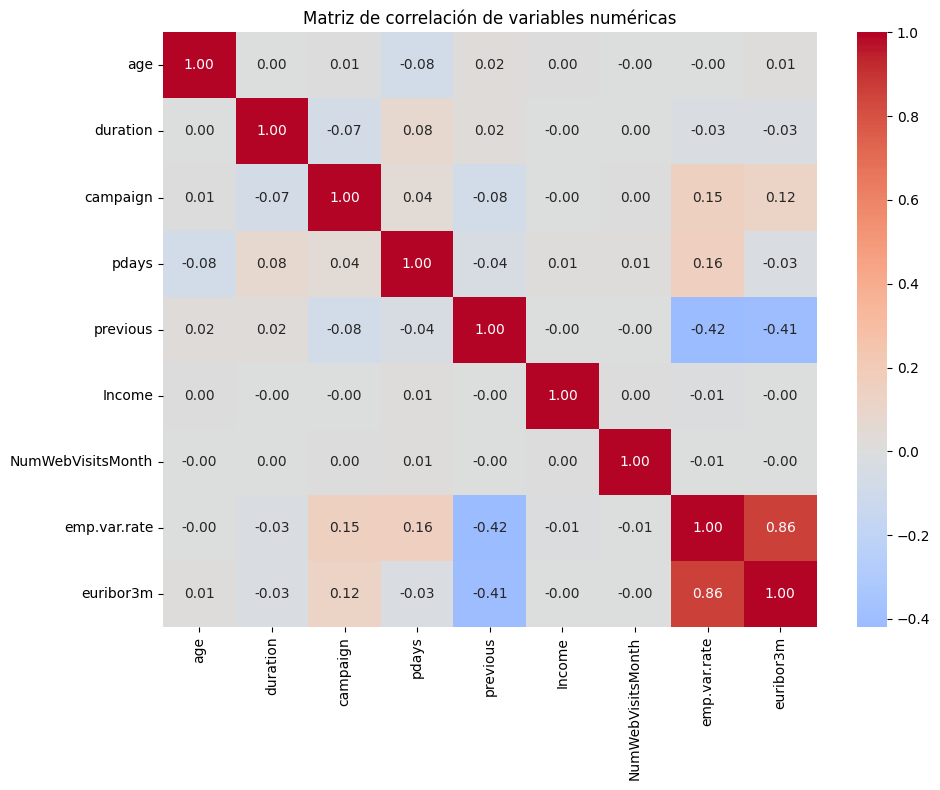

In [75]:
# Visualizamos la matriz como un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de variables numéricas")
plt.tight_layout()
plt.savefig("../imagenes/matriz_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

### Tasa de conversión por variables categóricas

Analizamos si la profesión, el estado civil o el resultado de campañas anteriores están asociados a una mayor probabilidad de contratar el depósito.

In [76]:
# Tasa de conversión (% que contrata) por profesión
conversion_job = df_final.groupby("job")["y"].value_counts(normalize=True).unstack()
conversion_job = conversion_job.sort_values(by="yes", ascending=False)
conversion_job

y,no,yes
job,,
student,0.686384,0.313616
retired,0.747475,0.252525
unemployed,0.855524,0.144476
admin.,0.870209,0.129791
desconocido,0.886628,0.113372
management,0.888669,0.111331
self-employed,0.891436,0.108564
technician,0.891609,0.108391
housemaid,0.900627,0.099373


**Conversión por profesión:**

Los `student` (31.4%) y `retired` (25.3%) tienen, con diferencia, la tasa de conversión más alta. En el otro extremo, `blue-collar` (6.9%) y `services` (8.1%) son los perfiles menos receptivos. Esto sugiere que estudiantes y jubilados perfiles son los grupos mas interesantes para futuras campañas.

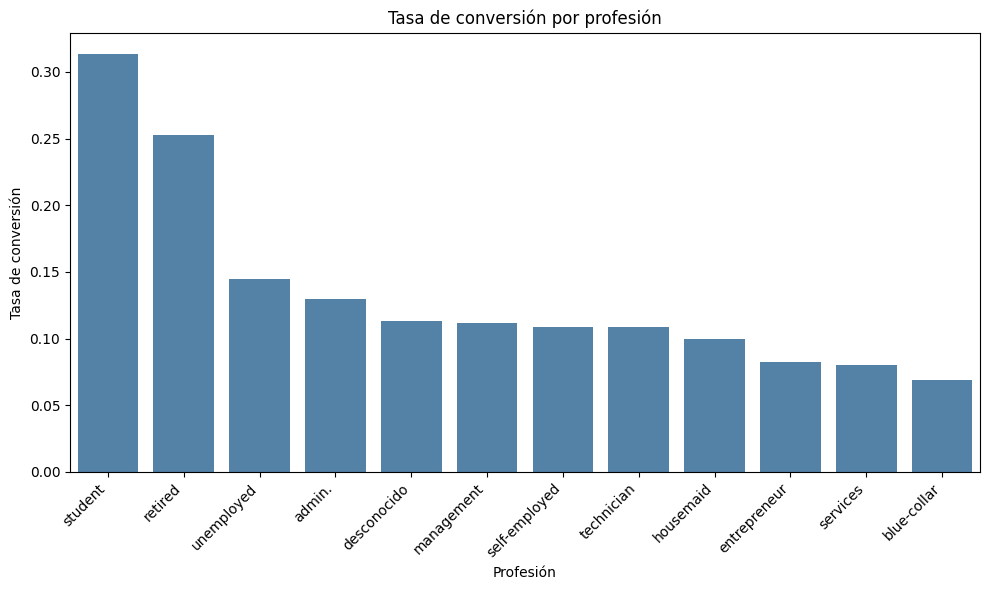

In [77]:
plt.figure(figsize=(10, 6))
sns.barplot(x=conversion_job.index, y=conversion_job["yes"], color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Tasa de conversión")
plt.xlabel("Profesión")
plt.title("Tasa de conversión por profesión")
plt.tight_layout()
plt.savefig("../imagenes/conversion_por_profesion.png", dpi=150, bbox_inches="tight")
plt.show()

In [78]:
# Tasa de conversión por estado civil
conversion_marital = df_final.groupby("marital")["y"].value_counts(normalize=True).unstack()
conversion_marital = conversion_marital.sort_values(by="yes", ascending=False)
conversion_marital

y,no,yes
marital,,
desconocido,0.847059,0.152941
single,0.860583,0.139417
married,0.898142,0.101858
divorced,0.898202,0.101798


**Conversión por estado civil :**

Las diferencias son menores que por profesión, pero los solteros (13.9%) dan el si algo más que los casados o divorciados (~10.2% en ambos).

In [79]:
# Tasa de conversión según el resultado de la campaña anterior con ese cliente
conversion_poutcome = df_final.groupby("poutcome")["y"].value_counts(normalize=True).unstack()
conversion_poutcome = conversion_poutcome.sort_values(by="yes", ascending=False)
conversion_poutcome

y,no,yes
poutcome,,
success,0.345722,0.654278
failure,0.857979,0.142021
nonexistent,0.911965,0.088035


**Conversión por resultado de campaña anterior:**

Este es el hallazgo más relevante de todo el análisis: los clientes cuya **campaña anterior fue un éxito** (`success`) contratan en el **65.4%** de los casos, frente a solo el 8.8% de quienes nunca fueron contactados antes (`nonexistent`) una diferencia bastante notoria. Esto confirma que el historial previo con el cliente es, con diferencia, el mejor
predictor de conversión disponible en el dataset, muy por encima de cualquier variable numérica o demográfica.

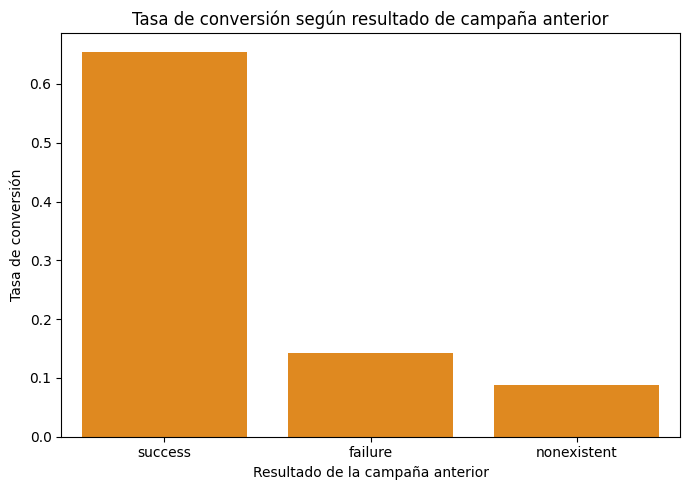

In [80]:
plt.figure(figsize=(7, 5))
sns.barplot(x=conversion_poutcome.index, y=conversion_poutcome["yes"], color="darkorange")
plt.ylabel("Tasa de conversión")
plt.xlabel("Resultado de la campaña anterior")
plt.title("Tasa de conversión según resultado de campaña anterior")
plt.tight_layout()
plt.savefig("../imagenes/conversion_poutcome.png", dpi=150, bbox_inches="tight")
plt.show()

### Distribución de variables clave y evolución temporal

Seleccionamos estas tres visualizaciones porque cada una responde a un
tipo de pregunta distinta:

- **Edad**: no está ligada directamente a la conversión, pero es información de contexto sobre el perfil de cliente necesaria para entender a quién representa el dataset.
- **Duración de la llamada según conversión**: ya vimos en el análisis numérico que era la variable con mayor diferencia entre quienes contratan y quienes no.
- **Evolución mensual de la conversión**: hasta ahora solo habíamos comparado grupos, pero no la dimensión temporal. Este gráfico responde lo siguiente: ¿hay meses en los que la campaña funciona mejor?

DISTRIBUCIÓN DE LA EDAD 

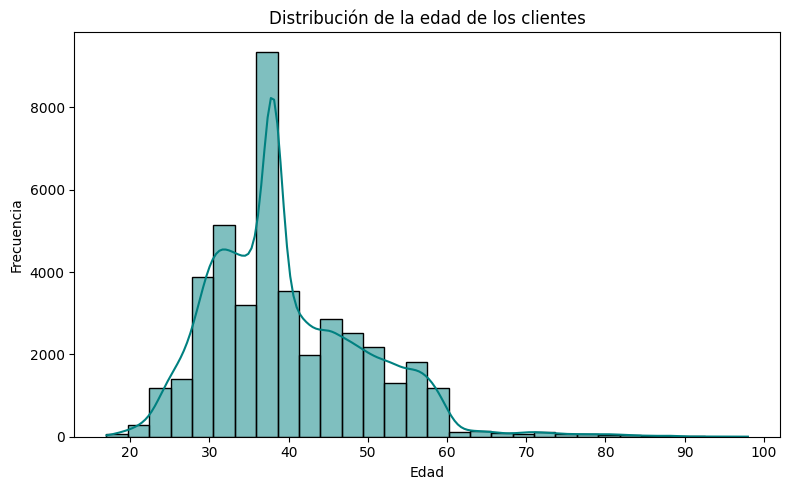

In [81]:
plt.figure(figsize=(8, 5))
sns.histplot(df_final["age"], bins=30, kde=True, color="teal")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.title("Distribución de la edad de los clientes")
plt.tight_layout()
plt.savefig("../imagenes/distribucion_edad.png", dpi=150, bbox_inches="tight")
plt.show()

**Distribución de la edad:** la mayoría de los clientes se concentra entre los 30 y los 45 años, con un pico muy marcado alrededor de los 35-38. A partir de los 60 años apenas hay clientes, así que la base de clientes es claramente de adultos en edad laboral.

DURACIÓN DE LLAMADA: CONTRATAN VS NO CONTRATAN (BOXPLOT)

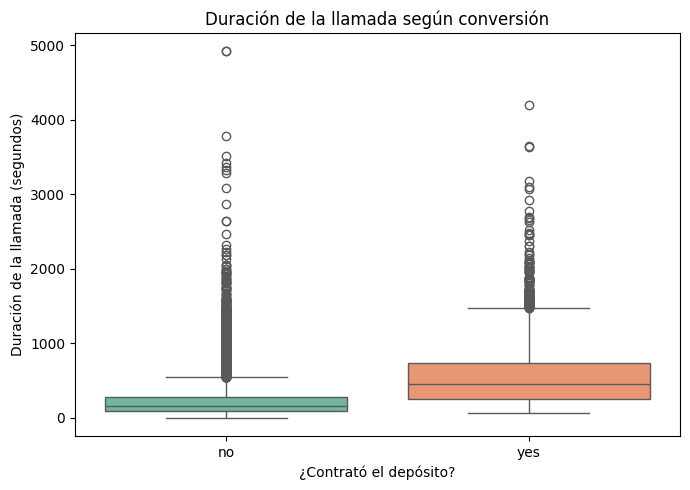

In [82]:
# Comparamos visualmente la duración de la llamada entre ambos grupos,
# para reforzar el hallazgo numérico visto antes
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_final, x="y", y="duration", hue="y", palette="Set2", legend=False) #Aquí a tuve muchos errores en la hora de eleccion de colores y codificación correcta de las cajas
plt.xlabel("¿Contrató el depósito?")
plt.ylabel("Duración de la llamada (segundos)")
plt.title("Duración de la llamada según conversión")
plt.tight_layout()
plt.savefig("../imagenes/duracion_vs_conversion.png", dpi=150, bbox_inches="tight")
plt.show()

**Duración de la llamada según conversión:** el boxplot confirma visualmente lo que ya habíamos visto en los números, la caja de "yes" está desplazada hacia arriba respecto a la de "no", con una mediana muy superior. Aun así, ambos grupos tienen llamadas muy largas puntuales (hasta 5.000 segundos), así que la duración por sí sola no garantiza la conversión, pero sí está claramente asociada a ella.

EVOLUCIÓN DE CONTRATACIONES POR MES 

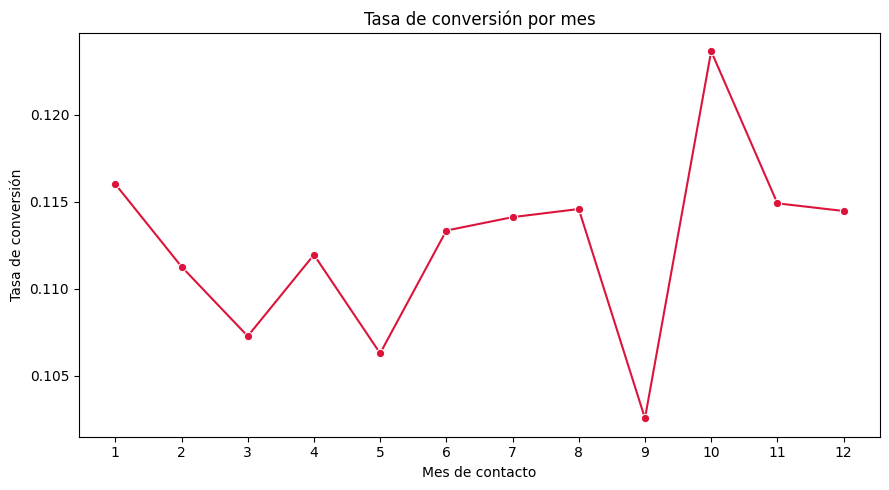

In [83]:
# Tasa de conversión por mes de contacto
conversion_mes = df_final.groupby("contact_month")["y"].value_counts(normalize=True).unstack()
plt.figure(figsize=(9, 5))
sns.lineplot(x=conversion_mes.index, y=conversion_mes["yes"], marker="o", color="crimson")
plt.xlabel("Mes de contacto")
plt.ylabel("Tasa de conversión")
plt.title("Tasa de conversión por mes")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig("../imagenes/conversion_por_mes.png", dpi=150, bbox_inches="tight")
plt.show()

**Tasa de conversión por mes:** hay un pico claro en octubre (~12.5%) y una caída notable en septiembre (<10%), justo el mes anterior. El resto del año se mantiene bastante estable, entre el 10.5% y el 11.6%, sin una tendencia estacional muy marcada más allá de ese repunte de octubre, que podría valer la pena investigar (quizá coincide con alguna campaña específica o cambio de estrategia).